# Test sliding window calculation - IMC Type 1 Diabetes Pancreas data

This tutorials shows how to set up an multiple slide spatial proteomics (IMC) dataset used from [Damond et al., 2019](https://doi.org/10.1016/j.cmet.2018.11.014). To follow along with this and the following tutorials, please execute the following steps first:

- Set up InterScale environment (see instructions in ReadMe)
- Download the sample data from the original publication from [Zenodo](https://zenodo.org/records/13907274)

In [46]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import issparse
import seaborn as sns

from pathlib import Path

In [68]:
import warnings
warnings.filterwarnings('ignore')

In [47]:
from pathlib import Path

# set INTERSCALE_DIR to the current working directory
INTERSCALE_DIR = Path.cwd()
print(INTERSCALE_DIR)

/workspace


<mark>TODO: Change data path</mark>

In [48]:
IMC_PANCREAS = '/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/data/spatial_proteomics_pancreas_t1d_IMC.h5ad'  

## Load data

In [5]:
adata_pancreas = sc.read_h5ad(IMC_PANCREAS)
adata_pancreas

AnnData object with n_obs × n_vars = 1776974 × 38
    obs: 'ImageNumber', 'ObjectNumber', 'Location_Center_X', 'Location_Center_Y', 'Number_Object_Number', 'image_name', 'id', 'CellCat', 'CellType', 'case', 'slide', 'part', 'group', 'stage', 'duration', 'Aab status', 'Age', 'Gender', 'Ethnicity', 'BMI'
    uns: 'morphology', 'neighbors', 'parent_structure'
    obsm: 'spatial'
    layers: 'MeanIntensity', 'MedianIntensity'

## 2. Calculate spatial connectivity matrix

Use [`squidpy.gr.spatial_neighbors()`](https://squidpy.readthedocs.io/en/stable/api/squidpy.gr.spatial_neighbors.html)) to calculate the spatial connectivity. For image-based ST it is important to set `coord_type='generic'`. In Squidpy, you have the option between k-nearest neighbors, delaunay and radius based neighborhood. For InterScale, we use a `radius`-based neighborhood to capture density information. Find the radius for which the number of connected neighbors is approximately 10-30, depending on tissue density. 

In [13]:
print('Nr. of images', len(np.unique(adata_pancreas.obs['ImageNumber'])))

Nr. of images 845


In [11]:
adata_pancreas.obs['ImageNumber'] = pd.Categorical(adata_pancreas.obs['ImageNumber'])

In [12]:
sq.gr.spatial_neighbors(
    adata_pancreas,
    coord_type = "generic",
    library_key = "ImageNumber",
    radius = 30,
)

In [13]:
# Calculate nr. of neighbors per cells
conn = adata_pancreas.obsp['spatial_connectivities']
# Print average number of connections per node
avg_connections = conn.nnz / conn.shape[0]  # total connections / number of nodes
print(f"Average number of connections per node: {avg_connections:.2f}")

Average number of connections per node: 25.22


/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


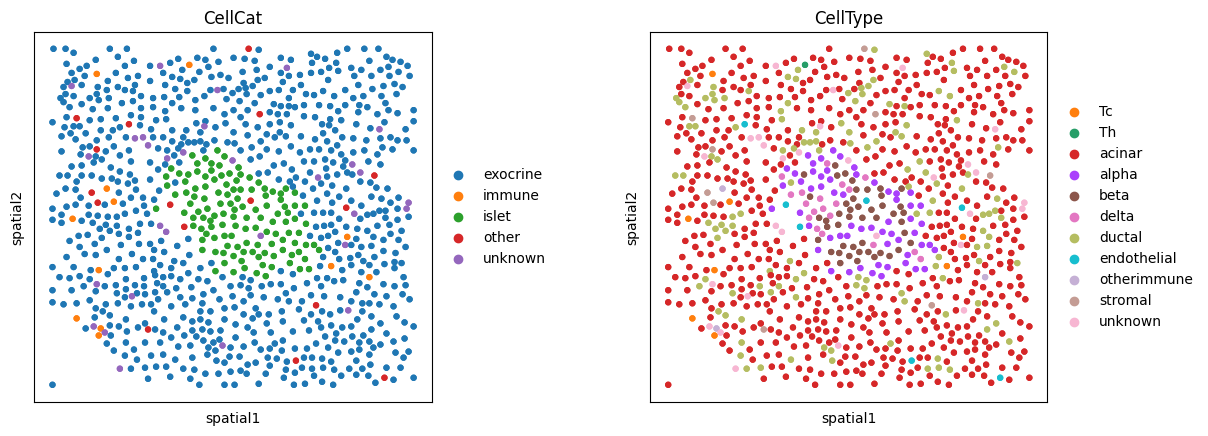

In [17]:
sq.pl.spatial_scatter(
            adata_pancreas,
            color = ['CellCat','CellType'],
            spatial_key = 'spatial',
            library_key='image_name',
            library_id=['M25'],
            shape= None,
            size=50
)

/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


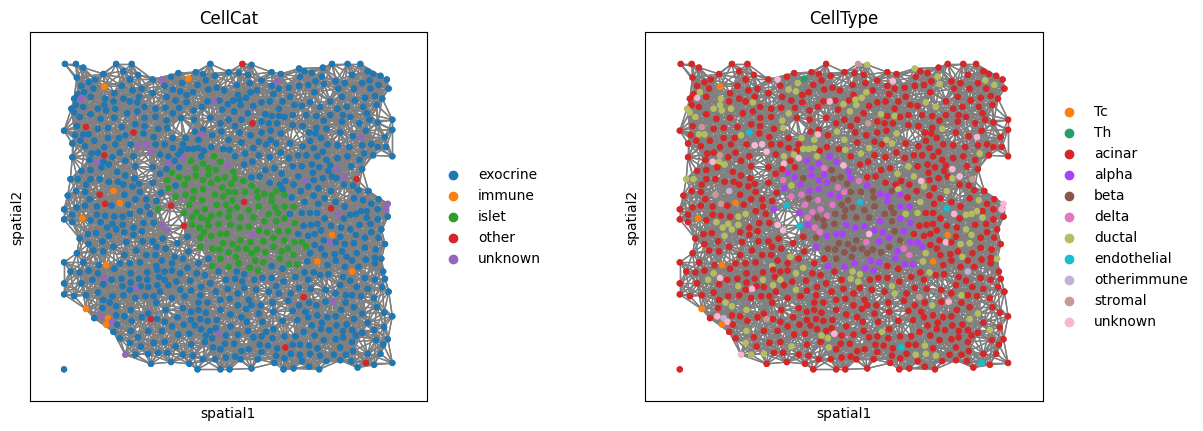

In [18]:
sq.pl.spatial_scatter(
            adata_pancreas,
            color = ['CellCat','CellType'],
            spatial_key = 'spatial',
            library_key='image_name',
            library_id=['M25'],
            shape= None,
            connectivity_key="spatial_connectivities",
            size=50
)

## 3. Optional: Calculate sliding windows

Sliding windows are necessary in case the tissue slide contains more than 4k cells. First, check how many cells are at minimum or maximum in your dataset.

In [14]:
tissue_cell_number = adata_pancreas.obs.groupby('ImageNumber').size()
print(f"Nr cells per sliding window: Min: {tissue_cell_number.min()}, Max: {tissue_cell_number.max()}, Avg: {tissue_cell_number.mean()}")

Nr cells per sliding window: Min: 521, Max: 9396, Avg: 2102.9278106508877


/tmp/ipykernel_1088497/3524064332.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tissue_cell_number = adata_pancreas.obs.groupby('ImageNumber').size()


Select images that have more than some MAX number of cells.

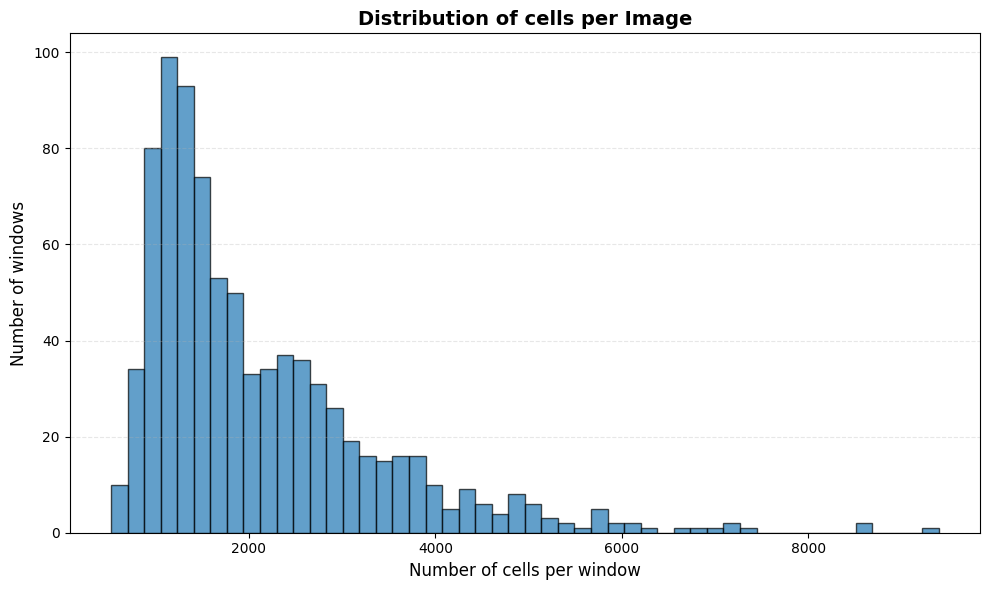

In [53]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram
ax.hist(tissue_cell_number, bins=50, edgecolor='black', alpha=0.7)

# Labels and title
ax.set_xlabel('Number of cells per window', fontsize=12)
ax.set_ylabel('Number of windows', fontsize=12)
ax.set_title('Distribution of cells per Image', fontsize=14, fontweight='bold')

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [39]:
MAX_NR_CELLS = 8000
MIN_NR_CELLS = 800
tissue_cell_number = adata_pancreas.obs.groupby('ImageNumber').size()
print(f'Images with less than {MIN_NR_CELLS} cells:', tissue_cell_number[tissue_cell_number < MIN_NR_CELLS])
print(f'Images with more than {MAX_NR_CELLS} cells:', tissue_cell_number[tissue_cell_number > MAX_NR_CELLS])

Images with less than 800 cells: ImageNumber
96     723
131    754
136    755
189    706
229    781
261    796
264    771
272    618
273    766
274    764
352    749
385    777
524    521
525    605
527    661
528    681
542    680
549    695
559    734
565    686
612    643
635    766
669    781
757    667
dtype: int64
Images with more than 8000 cells: ImageNumber
177    8662
408    9396
787    8590
dtype: int64


/tmp/ipykernel_1088497/3251425770.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tissue_cell_number = adata_pancreas.obs.groupby('ImageNumber').size()


/dss/dsshome1/05/di93tig/.local/lib/python3.10/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


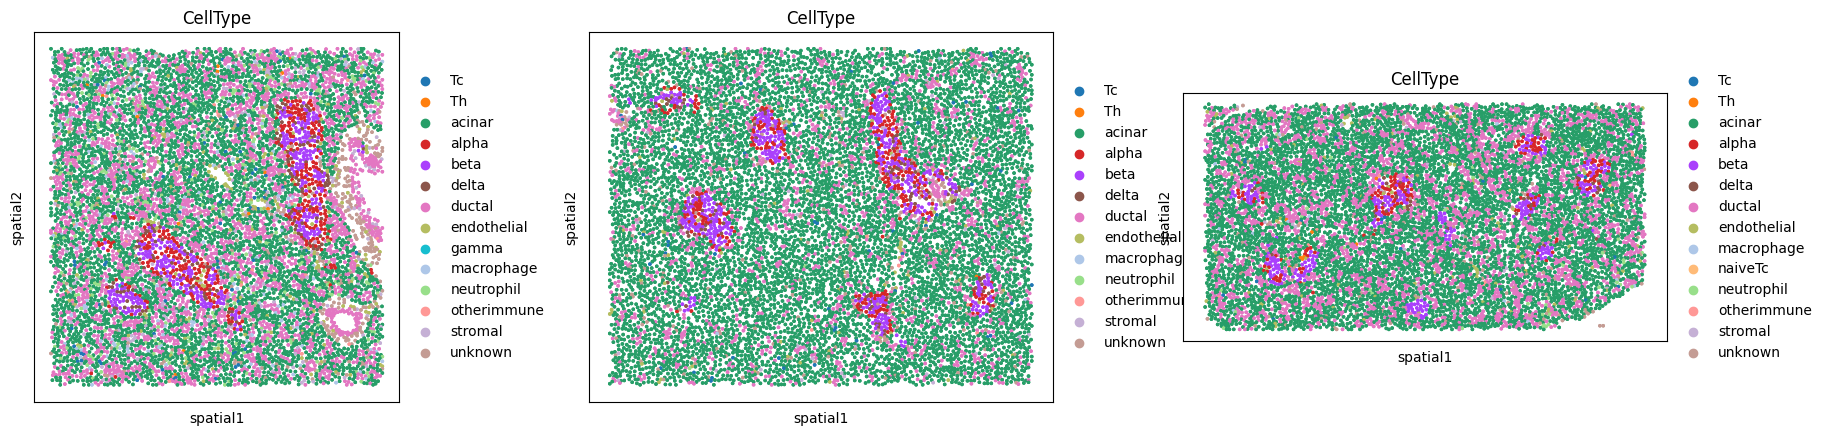

In [23]:
sq.pl.spatial_scatter(
    adata_pancreas[adata_pancreas.obs['ImageNumber'].isin([177, 408, 787])],
    spatial_key = 'spatial',
    library_key='ImageNumber', 
    #library_id = [839, 6],
    color="CellType", #cell_type_coarse",
    shape= None,
    size = 10,
)

In [25]:
# calculate sizes of images
adata_pancreas.obs['Location_Center_X']

0           52.500000
1          128.000000
2          135.285714
3          449.526316
4          458.366667
              ...    
1776969    299.032787
1776970    284.336957
1776971    134.000000
1776972    157.400000
1776973    374.750000
Name: Location_Center_X, Length: 1776974, dtype: float64

In [26]:
MAX_CELLS = 2500
tissue_cell_number = adata_pancreas.obs.groupby('ImageNumber').size()
batches_high_nr_cells = tissue_cell_number[tissue_cell_number > MAX_CELLS]
print(batches_high_nr_cells)

ImageNumber
1      4650
4      7147
5      3391
6      2518
7      3155
       ... 
837    2549
839    2836
840    3596
843    2980
844    3633
Length: 242, dtype: int64


/tmp/ipykernel_1088497/1254649840.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tissue_cell_number = adata_pancreas.obs.groupby('ImageNumber').size()


We observe that there are a slides with only a few cells but 2 slides with more than 4k cells. For this case we have the option to 1) increase the context length to max = 4875 or 2) calculate sliding windows for all slides that have more than 3k cells. 

In [27]:
# Use the index of batches_high_nr_cells to get the image numbers
sub_adata = adata_pancreas[adata_pancreas.obs['ImageNumber'].isin(batches_high_nr_cells.index)]
sub_adata

View of AnnData object with n_obs × n_vars = 893704 × 38
    obs: 'ImageNumber', 'ObjectNumber', 'Location_Center_X', 'Location_Center_Y', 'Number_Object_Number', 'image_name', 'id', 'CellCat', 'CellType', 'case', 'slide', 'part', 'group', 'stage', 'duration', 'Aab status', 'Age', 'Gender', 'Ethnicity', 'BMI'
    uns: 'morphology', 'neighbors', 'parent_structure', 'spatial_neighbors'
    obsm: 'spatial'
    layers: 'MeanIntensity', 'MedianIntensity', 'pct-norm-99'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [28]:
print(f"Nr cells per for large images: Min: {batches_high_nr_cells.min()}, Max: {batches_high_nr_cells.max()}, Avg: {batches_high_nr_cells.mean()}")

Nr cells per for large images: Min: 2502, Max: 9396, Avg: 3692.99173553719


In [29]:
sq.tl.sliding_window(
    adata=sub_adata,
    library_key="ImageNumber",  # to stratify by sample
    window_size=600,
    overlap=0,
    copy=False,  # we modify in place
)

/usr/local/lib/python3.10/dist-packages/squidpy/gr/_utils.py:203: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  obj[key] = data


In [30]:
window_size = sub_adata.obs.groupby('sliding_window_assignment').size()
print(f"Nr cells per sliding window: Min: {window_size.min()}, Max: {window_size.max()}, Avg: {window_size.mean()}")

Nr cells per sliding window: Min: 2, Max: 4606, Avg: 1616.1012658227849


/tmp/ipykernel_1088497/1767285025.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  window_size = sub_adata.obs.groupby('sliding_window_assignment').size()


In [31]:
sub_adata.obs["ImageNumber"]

0            1
1            1
2            1
3            1
4            1
          ... 
1775785    844
1775786    844
1775787    844
1775788    844
1775789    844
Name: ImageNumber, Length: 893704, dtype: category
Categories (242, int64): [1, 4, 5, 6, ..., 839, 840, 843, 844]

With the sliding windows the maximum number of cells per sliding window is `2418`. 

<mark>TODO: Adjust max_seq_len in config file!</mark>
Given this we adjust the `max_seq_len` from the model.global_component to `2418`. The default is `2000`.

In [48]:
del sub_adata.uns['sliding_window_assignment_colors']

/dss/dsshome1/05/di93tig/.local/lib/python3.10/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


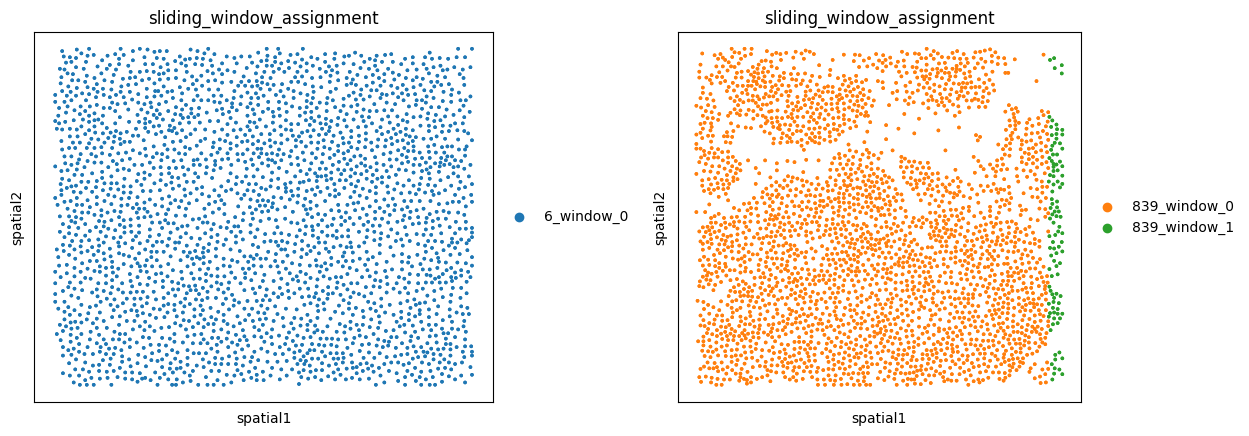

In [32]:
sq.pl.spatial_scatter(
    sub_adata[sub_adata.obs['ImageNumber'].isin([839, 6])],
    spatial_key = 'spatial',
    library_key='ImageNumber', 
    #library_id = [839, 6],
    color="sliding_window_assignment", #cell_type_coarse",
    shape= None,
    size = 10,
)

/dss/dsshome1/05/di93tig/.local/lib/python3.10/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


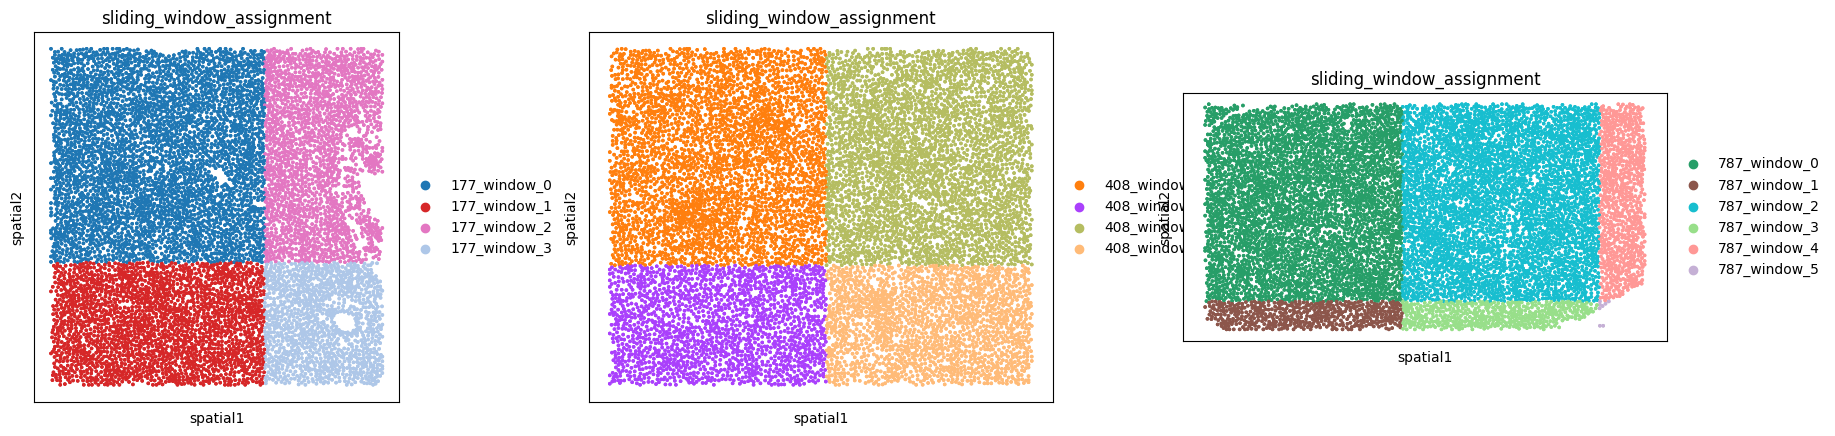

In [33]:
sq.pl.spatial_scatter(
    sub_adata[sub_adata.obs['ImageNumber'].isin([177, 408, 787])],
    spatial_key = 'spatial',
    library_key='ImageNumber', 
    #library_id = [839, 6],
    color="sliding_window_assignment", #cell_type_coarse",
    shape= None,
    size = 10,
)

/dss/dsshome1/05/di93tig/.local/lib/python3.10/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


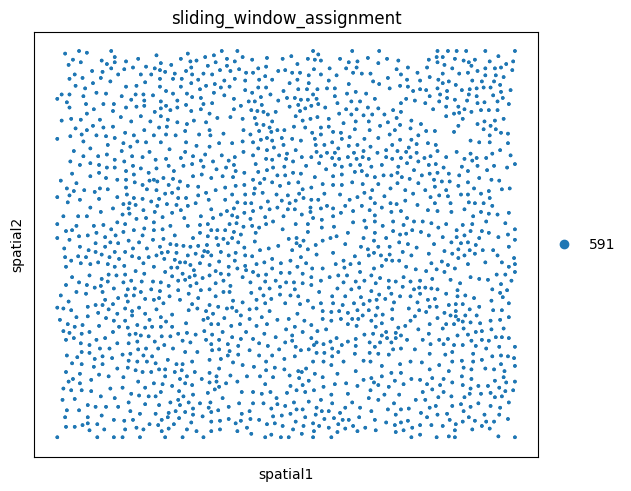

In [62]:
sq.pl.spatial_scatter(
    adata_pancreas[adata_pancreas.obs['ImageNumber'].isin([845])],
    spatial_key = 'spatial',
    library_key='ImageNumber', 
    #library_id = [839, 6],
    color="sliding_window_assignment", #cell_type_coarse",
    shape= None,
    size = 10,
)

In [81]:
# Store ImageNumbers with small windows
images_with_small_windows = []
all_window_counts = np.array([])

for img_nr in np.unique(adata_pancreas.obs['ImageNumber']):
    sub_adata = adata_pancreas[adata_pancreas.obs['ImageNumber'] == img_nr]
    window_counts = sub_adata.obs.groupby(['sliding_window_assignment']).size()
    all_window_counts = np.append(all_window_counts, window_counts.values)
    
    # Check if any window has < 500 cells
    small_windows = window_counts[window_counts < 500]
    
    if len(small_windows) > 0:
        images_with_small_windows.append(img_nr)
        print(f"\nImageNumber {img_nr}:")
        print(f"  Windows with < 500 cells: {len(small_windows)}")
        print(f"  Window counts:\n{window_counts}")

print(f"\n{'='*50}")
print(f"Total ImageNumbers with windows < 500 cells: {len(images_with_small_windows)}")
print(f"Affected ImageNumbers: {images_with_small_windows}")


ImageNumber 1:
  Windows with < 500 cells: 2
  Window counts:
sliding_window_assignment
1_window_0    3174
1_window_1     301
1_window_3      99
1_window_2    1076
dtype: int64

ImageNumber 7:
  Windows with < 500 cells: 1
  Window counts:
sliding_window_assignment
7_window_0    2691
7_window_1     464
dtype: int64

ImageNumber 14:
  Windows with < 500 cells: 1
  Window counts:
sliding_window_assignment
14_window_0    2855
14_window_1     344
dtype: int64

ImageNumber 15:
  Windows with < 500 cells: 1
  Window counts:
sliding_window_assignment
15_window_1      23
15_window_0    2551
dtype: int64

ImageNumber 16:
  Windows with < 500 cells: 1
  Window counts:
sliding_window_assignment
16_window_0    3089
16_window_2     661
16_window_1     947
16_window_3     197
dtype: int64

ImageNumber 19:
  Windows with < 500 cells: 2
  Window counts:
sliding_window_assignment
19_window_2    1435
19_window_1     100
19_window_0    3243
19_window_3      59
dtype: int64

ImageNumber 21:
  Windows wit

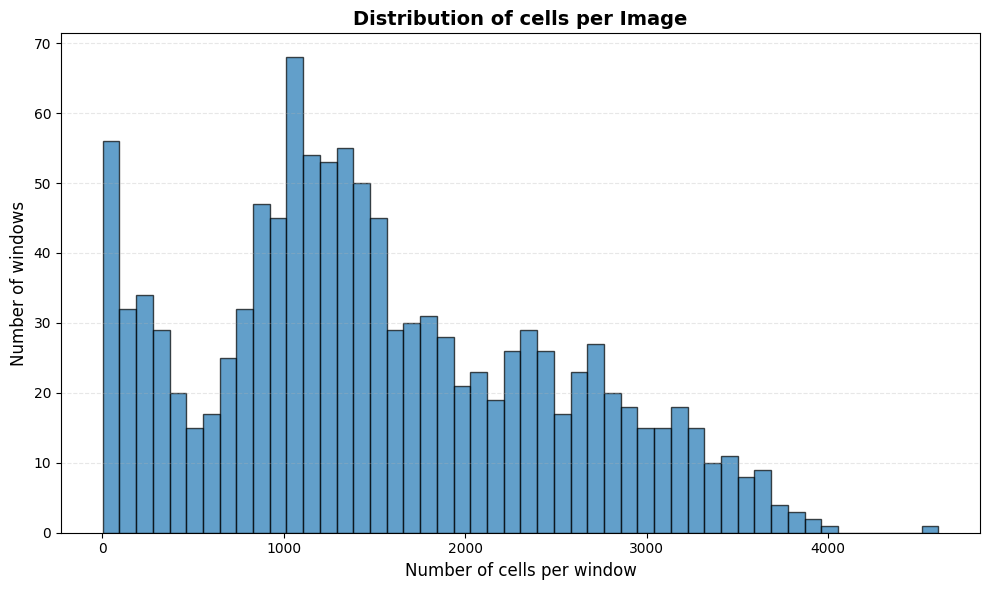

In [83]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram
ax.hist(all_window_counts, bins=50, edgecolor='black', alpha=0.7)

# Labels and title
ax.set_xlabel('Number of cells per window', fontsize=12)
ax.set_ylabel('Number of windows', fontsize=12)
ax.set_title('Distribution of cells per Image', fontsize=14, fontweight='bold')

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

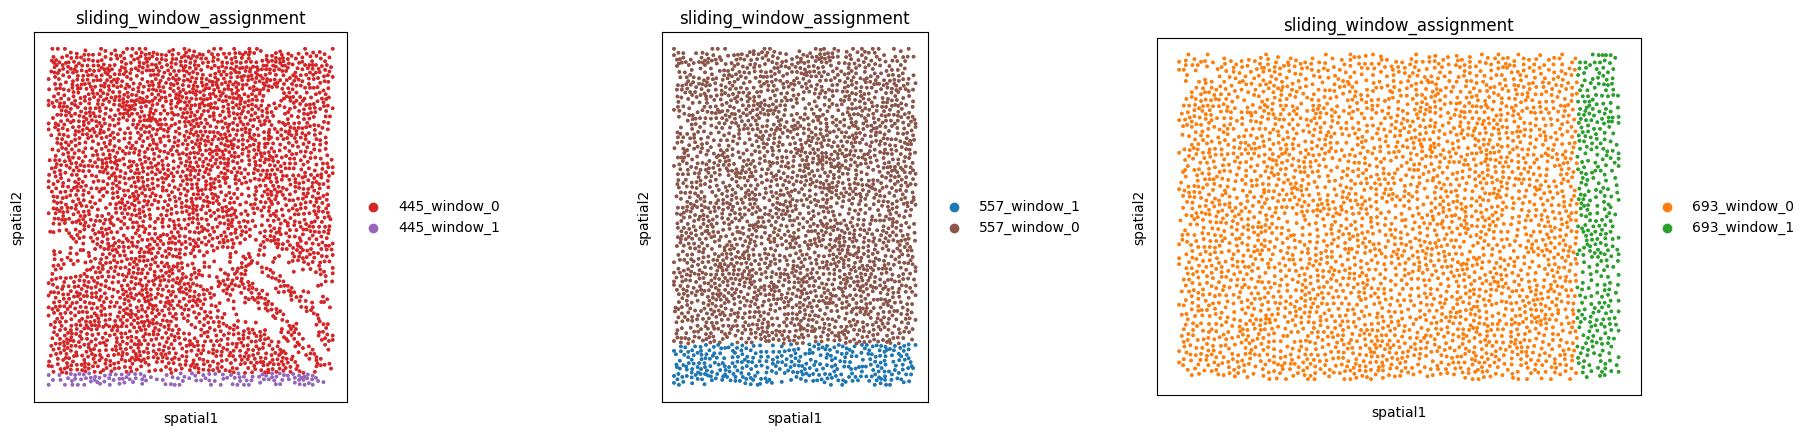

In [89]:
sq.pl.spatial_scatter(
    adata_pancreas[adata_pancreas.obs['ImageNumber'].isin(np.random.choice(images_with_small_windows, 3))],
    spatial_key = 'spatial',
    library_key='ImageNumber', 
    #library_id = [839, 6],
    color="sliding_window_assignment", #cell_type_coarse",
    shape= None,
    size = 10
)

Are all FOV sizes and window sizes equal? 

In [91]:
image_sizes = []

for img_nr in np.unique(adata_pancreas.obs['ImageNumber']):
    sub_adata = adata_pancreas[adata_pancreas.obs['ImageNumber'] == img_nr]
    
    # Get spatial coordinates
    spatial_coords = sub_adata.obsm['spatial']
    
    # Calculate x and y distances
    x_min, x_max = spatial_coords[:, 0].min(), spatial_coords[:, 0].max()
    y_min, y_max = spatial_coords[:, 1].min(), spatial_coords[:, 1].max()
    
    x_distance = x_max - x_min
    y_distance = y_max - y_min
    
    image_sizes.append({
        'ImageNumber': img_nr,
        'x_distance': x_distance,
        'y_distance': y_distance,
        'area': x_distance * y_distance,
        'n_cells': sub_adata.n_obs
    })

# Convert to DataFrame for easy viewing
size_df = pd.DataFrame(image_sizes)
size_df = size_df.sort_values('area', ascending=False)

print(size_df)
print(f"\nSummary:")
print(size_df[['x_distance', 'y_distance', 'area']].describe())

     ImageNumber  x_distance  y_distance       area  n_cells
407          408      1168.0       930.0  1086240.0     9396
786          787      1337.0       685.0   915845.0     8590
176          177       930.0       943.0   876990.0     8662
405          406       750.0      1069.0   801750.0     6372
214          215       969.0       826.0   800394.0     7302
..           ...         ...         ...        ...      ...
135          136       272.0       286.0    77792.0      755
668          669       286.0       265.0    75790.0      781
524          525       269.0       281.0    75589.0      605
271          272       268.0       264.0    70752.0      618
523          524       276.0       253.0    69828.0      521

[845 rows x 5 columns]

Summary:
        x_distance  y_distance          area
count   845.000000   845.00000  8.450000e+02
mean    478.695858   445.47574  2.265688e+05
std     159.072768   131.65994  1.375673e+05
min     266.000000   224.00000  6.982800e+04
25%     3

In [ ]:
size_df['1']

 Combine `sub_adata` with original `adata` object and transfer the sliding_window_assignment into original data.

In [37]:
adata_pancreas.obs['sliding_window_assignment'] = adata_pancreas.obs['ImageNumber'].astype(str)

# Get all unique categories from both sources
all_categories = list(set(adata_pancreas.obs['ImageNumber'].astype(str).unique()) | 
                     set(sub_adata.obs['sliding_window_assignment'].astype(str).unique()))

# Convert to categorical with all categories
adata_pancreas.obs['sliding_window_assignment'] = pd.Categorical(
    adata_pancreas.obs['sliding_window_assignment'],
    categories=all_categories
)

# Now update the subset
adata_pancreas.obs.loc[sub_adata.obs.index, 'sliding_window_assignment'] = sub_adata.obs['sliding_window_assignment'].astype(str)

In [49]:
# check which and how many slides have windows with less than 1K cells, if not too many we can just remove them until sliding window is fixed
# Get summary statistics
window_counts = adata_pancreas.obs.groupby('sliding_window_assignment').size()
small_windows = window_counts[window_counts < 500]

print(f"Total windows: {len(window_counts)}")
print(f"Windows with < 500 cells: {len(small_windows)} ({100*len(small_windows)/len(window_counts):.1f}%)")
print(f"Smallest window: {small_windows.min()} cells")

Total windows: 1398
Windows with < 500 cells: 421 (30.1%)
Smallest window: 0 cells


/tmp/ipykernel_1088497/3314766474.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  window_counts = adata_pancreas.obs.groupby('sliding_window_assignment').size()
